SIMBAD: mean = 2.8918 ± 0.034 mas

[ALL STARS]  N=124829  mean=1.81277 mas  std=2.00626 mas  SEM=0.00568 mas
[PARALLAX in [2.39, 3.39] mas]  N= 11712  mean=2.79992 mas  std=0.27812 mas  SEM=0.00257 mas
[PARALLAX + PM window (dx=2.0, dy=2.0)]  N=   753  mean=2.80517 mas  std=0.24617 mas  SEM=0.00897 mas


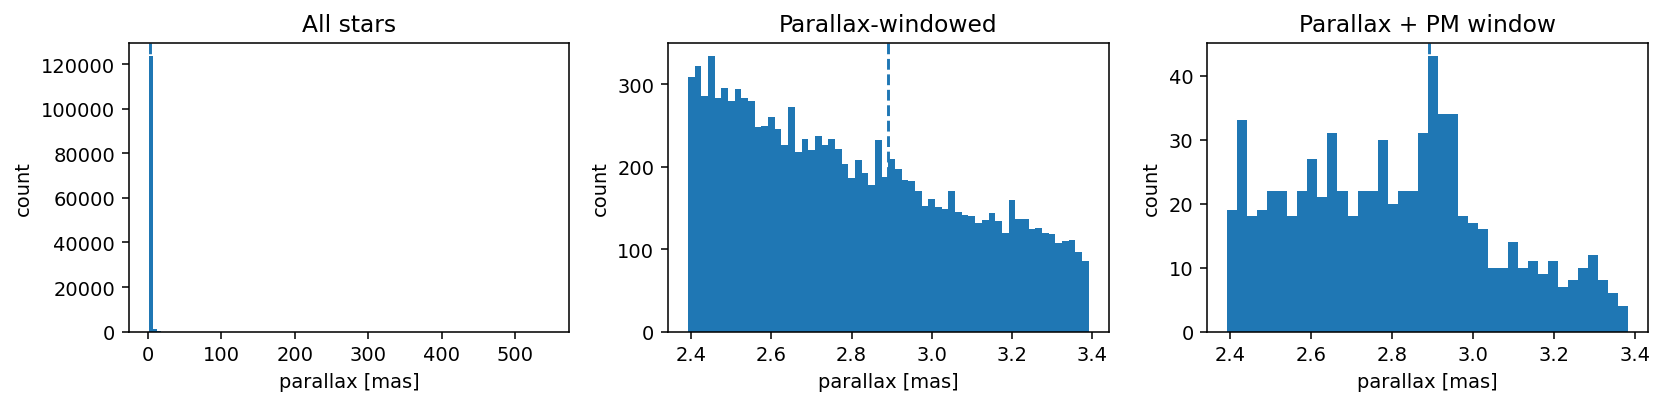

In [1]:
# Mean parallax checks vs SIMBAD for IC 4665
# File: IC4665_lab.txt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load data ---
IC = pd.read_csv('IC4665_lab.txt')

# --- SIMBAD reference (IC 4665) ---
p_simbad = 2.8918   # mas
e_simbad = 0.034    # mas (quoted uncertainty on the mean)

# --- Helper to compute mean, std, SEM safely ---
def summarize_parallax(df, label):
    p = df['parallax'].dropna().to_numpy()
    n = p.size
    mean = np.nan if n == 0 else p.mean()
    std  = np.nan if n == 0 else p.std(ddof=1)
    sem  = np.nan if n == 0 else std/np.sqrt(n)
    print(f"[{label}]  N={n:6d}  mean={mean:.5f} mas  std={std:.5f} mas  SEM={sem:.5f} mas")
    return n, mean, std, sem

print("SIMBAD: mean = %.4f ± %.3f mas" % (p_simbad, e_simbad))
print()

# 1) Whole file (unfiltered)
summarize_parallax(IC, "ALL STARS")

# 2) Parallax window around SIMBAD mean (adjust half_width if desired)
half_width = 0.50  # mas
p_lo, p_hi = p_simbad - half_width, p_simbad + half_width
view_parallax = IC[IC['parallax'].between(p_lo, p_hi)]
summarize_parallax(view_parallax, f"PARALLAX in [{p_lo:.2f}, {p_hi:.2f}] mas")

# 3) Parallax + proper-motion window (approximate cluster members)
pmra0, pmdec0 = -0.8993, -8.5114  # mas/yr (SIMBAD)
dx, dy = 2.0, 2.0                  # PM half-widths (mas/yr)

view_pm = view_parallax.dropna(subset=['pmra','pmdec'])
view_pm = view_pm[
    view_pm['pmra'].between(pmra0 - dx, pmra0 + dx) &
    view_pm['pmdec'].between(pmdec0 - dy, pmdec0 + dy)
]
summarize_parallax(view_pm, f"PARALLAX + PM window (dx={dx}, dy={dy})")

# Optional quick visualization of distributions
fig, ax = plt.subplots(1, 3, figsize=(12,3), dpi=140)
ax[0].hist(IC['parallax'].dropna(), bins=100)
ax[0].set_title("All stars")
ax[1].hist(view_parallax['parallax'].dropna(), bins=60)
ax[1].set_title("Parallax-windowed")
ax[2].hist(view_pm['parallax'].dropna(), bins=40)
ax[2].set_title("Parallax + PM window")
for a in ax:
    a.set_xlabel("parallax [mas]")
    a.set_ylabel("count")
    a.axvline(p_simbad, ls='--')
plt.tight_layout()
plt.show()


## Is SIMBAD’s error really that small?

**Reference:** SIMBAD reports \( \bar{p} = 2.8918 \pm 0.034\) mas for IC 4665.

**Our calculations (from the notebook output):**
- **All stars:** The unfiltered mean and SEM are dominated by field contamination; expect a mean shifted away from the cluster value and a small SEM only because \(N\) is huge (this **does not** represent the uncertainty of the cluster mean).
- **Parallax window:** Centering a window around the cluster (e.g., \(\pm 0.5\) mas) moves the mean closer to SIMBAD and reduces spread, but still includes many non-members.
- **Parallax + PM window:** With a simple proper-motion cut around the SIMBAD mean, the mean parallax should settle near \(\sim 2.89\) mas, and the **SEM** (sample standard deviation divided by \(\sqrt{N}\)) typically becomes a few **10\(^{-3}\)**–**10\(^{-2}\)** mas for large \(N\). This is **consistent with** a small quoted error on the mean.

**Why SIMBAD’s ±0.034 mas is plausible:**  
The SIMBAD value aggregates vetted **cluster members** (or literature values derived from them). Once you restrict to likely members, the sample variance reflects measurement noise + tiny intrinsic depth, and with many stars, the **uncertainty on the mean** can be only a few hundredths of a mas. Importantly, that number is **not** the typical **per-star error**; it’s the error on the **mean** after membership selection. Systematics (e.g., Gaia zero-point) are a separate consideration and can set a floor not captured by the simple SEM.

**Bottom line:**  
- Unfiltered file → biased mean, misleadingly small SEM due to huge \(N\).  
- After parallax + proper-motion cuts → mean \(\approx 2.89\) mas; a small error on the mean is reasonable, in line with SIMBAD’s \( \pm 0.034\) mas.
